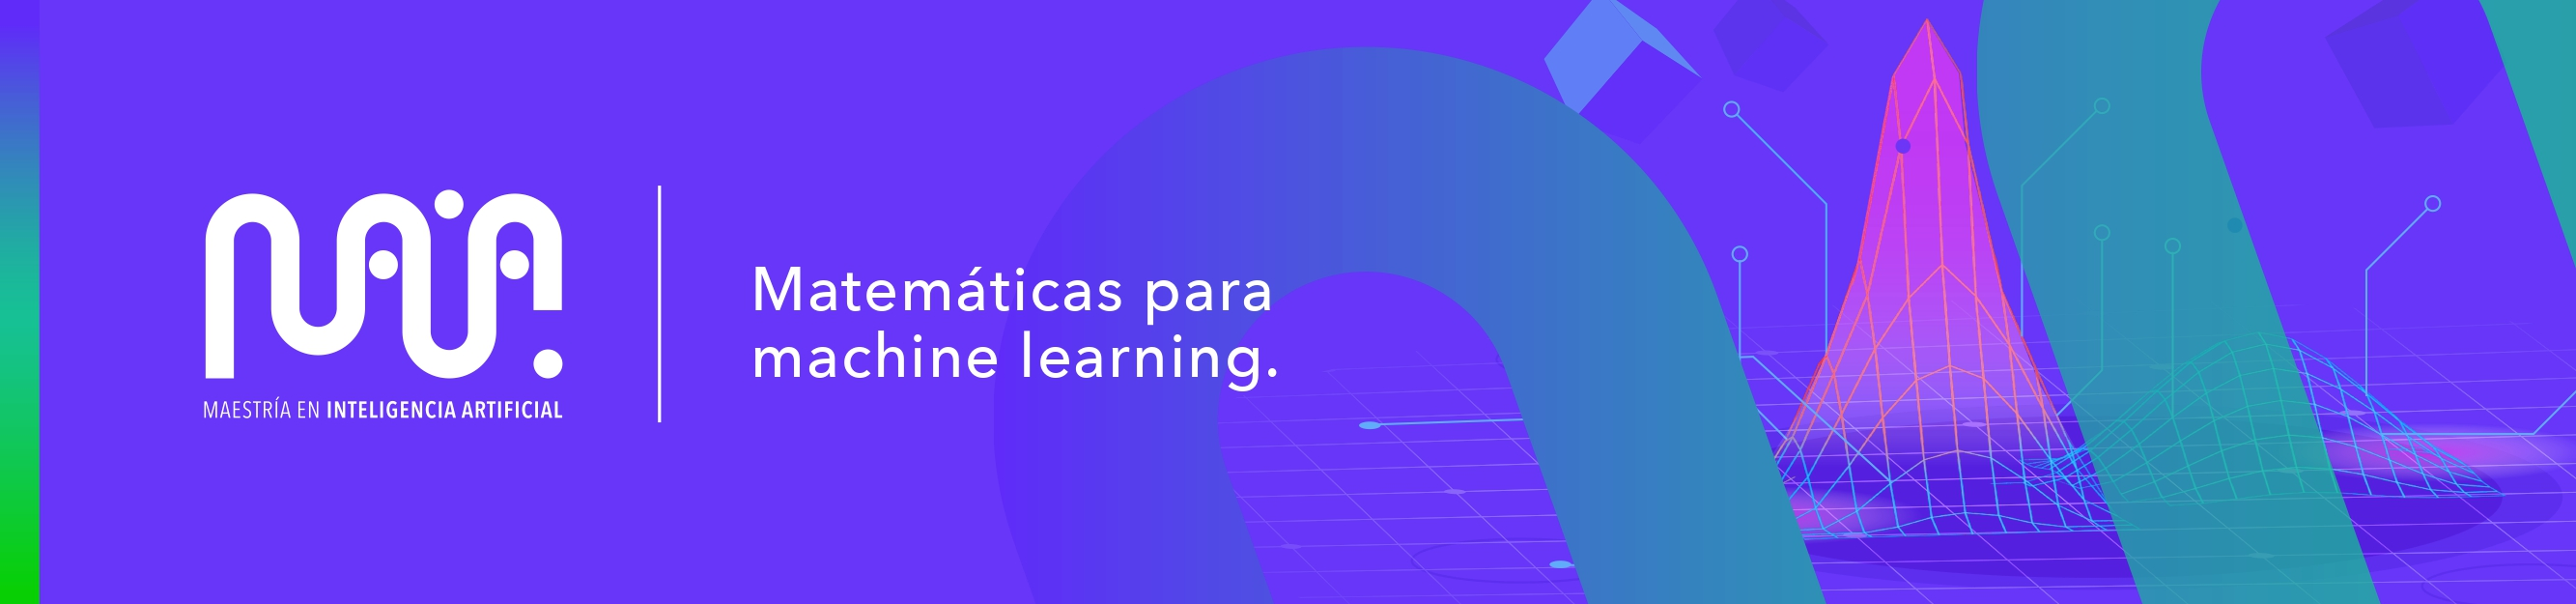

## **Laboratorio: resolución de problemas de programación lineal usando  *linprog***

Recordemos que los problemas de programación lineales son problemas de optimización en los que la función objetivo y las restricciones se definen como
combinaciones lineales de las variables de decisión. Este tipo de problemas de optimización son importantes en machine learning para resolver problemas donde se aplica la norma L1 y distancias de Manhattan para obtener modelos que al final del proceso de aprendizaje tengan pocos parámetros y se entrenen usando una cantidad grande de datos. También, son ampliamente usados para optimizar el uso de recursos computacionales durante el entrenamiento y despliegue de modelos en sistemas a larga escala. En este laboratorio, estudiaremos el método *linprog* de la librería scipy para solucionar problemas de optimización de tipo lineal. Para facilidad en la explicación del uso de este método en Python, usaremos ejemplos ilustrativos de juguete.

# **Introducción a linprog**

Un problema de programación lineal puede ser descrito de la siguiente forma:

$$\min_{x} c^T x$$
sujeto a:
$$Ax \leq b$$

donde $c$ es el vector de coeficientes de la función objetivo, $A$ es la matriz de coeficientes de las restricciones y $b$ es el vector de valores de las restricciones.

Por ejemplo, suponga que quiere maximizar la ganancia de una empresa que se dedica a la fabricación de sillas y mesas con la siguiente información:

- El precio unitario por silla es de 50 y por mesa es de 100.

- Para producir una silla se necesitan 2 unidades de madera.

- Para producir una mesa se necesitan 5 unidades de madera.

- Hay un total de 60 unidades de madera disponibles para fabricación.

- Solo hay 40 horas de producción disponibles.

- Elaborar una mesa toma 2 horas y elaborar una silla toma 1 hora.

- Se deben fabricar máximo 10 sillas.

Recordemos que un problema de optimización tiene tres componentes: las variables de decisión, la región factible, y la función objetivo. En este caso, las variables de decisión serían la cantidad de sillas $x_1$ y la cantidad de mesas $x_2$. La función objetivo se puede definir entonces como las ganancias por sillas y mesas producidas, esto es, $50 x_1 + 100 x_2$. Usando el resto de la información dada, podemos contruir el siguiente problema de optimización:
$$\max_{x} 50 x_1 + 100 x_2$$

sujeto a:

$$2x_1 + 5x_2 \leq 60$$

$$x_1 + 2x_2 \leq 40$$

$$x_1 \leq 10$$

$$x_1, x_2 \geq 0$$

Dado que la función linprog minimiza, se toma el negativo de la función objetivo. Es decir, el problema queda de la siguiente manera:

$$\min_{x} -50 x_1 -100 x_2$$

sujeto a:

$$2x_1 + 5x_2 \leq 60$$

$$x_1 + 2x_2 \leq 40$$

$$x_1 \leq 10$$

$$x_1, x_2 \geq 0$$

Al plantear este problema en términos de los vectores $c^T, b$ y la matriz $A$ mencionados anteriormente se tiene lo siguiente:

$$\min_{x} c^T x$$
sujeto a:
$$Ax \leq b$$
donde:
$$c = [-50,-100]^T$$

$$A = \begin{bmatrix}
2 & 5\\
1 & 2\\
1 & 0
\end{bmatrix}$$

$$b = [60, 40, 10]^T$$
$$x_1, x_2 \geq 0, $$

Las restricciones de no negatividad de las variables de decisión las dejamos por fuera de la expresión $Ax\le b$ ya que la función *linprog* nos permite definir, a parte, los límites superiores e inferiores de las variables de decisión. En este problema particular, asumimos que las variables de decisión son variables reales.

# **Instrucciones de programación**

En primer lugar, se importa la función *linprog* del paquete *scipy.optimize*

In [16]:
from scipy.optimize import linprog
import matplotlib.pyplot as plt
import numpy as np


A continuación, se definen los parámetros de nuestro problema:

In [3]:
c = [-50,-100]

A = [[2,5],[1,2],[1,0]]

b = [60,40,10]

Por último, se definen los límites de las variables; en este caso, $x_1, x_2 \geq 0$.

In [2]:
bounds = [(0,None),(0,None)]

Dado que las restricciones están planteadas de la forma $Ax \leq b$, se hace uso de los argumentos *A_ub* y *b_ub*. En caso de que las restricciones estén planteadas de la forma $Ax = b$, se debe hacer uso de los parámetros *A_eq* y *b_eq*.

In [4]:
solucion = linprog(c,A_ub = A, b_ub = b, bounds=bounds)

In [5]:
solucion

        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: -1300.0
              x: [ 1.000e+01  8.000e+00]
            nit: 0
          lower:  residual: [ 1.000e+01  8.000e+00]
                 marginals: [ 0.000e+00  0.000e+00]
          upper:  residual: [       inf        inf]
                 marginals: [ 0.000e+00  0.000e+00]
          eqlin:  residual: []
                 marginals: []
        ineqlin:  residual: [ 0.000e+00  1.400e+01  0.000e+00]
                 marginals: [-2.000e+01 -0.000e+00 -1.000e+01]
 mip_node_count: 0
 mip_dual_bound: 0.0
        mip_gap: 0.0

En este caso, el mínimo de la función está en el atributo *fun* de la variable solución y el minimizador se encuentra en el atributo *x*. Dado que inicialmente se buscaba maximizar la ganancia se toma el negativo del atributo *fun* como ganancia. Es decir, la ganancia máxima que se puede lograr es de 1300 y se logra vendiendo 10 sillas y 8 mesas. Esta es una solución que satisface las restricciones y maximiza las ganancias obtenidas.

# **Ejercicios**

**1.** Asuma que realizó una ampliación de la fábrica e invirtió más dinero para obtener más materia prima y ahora tiene 80 unidades de recursos disponibles y 50 horas de trabajo disponibles. Modifique el siguiente código para que refleje los cambios descritos anteriormente:

In [23]:
c = [-50,-100]

A = [[2,5],[1,2],[1,0]]

#Modifique el siguiente vector teniendo en cuenta los valores dados en el enunciado.
b = [80,50,10]

bounds = [(0,None),(0,None)]

solucion = linprog(c,A_ub = A, b_ub = b, bounds=bounds)

vector_optimo = solucion.x
valor_objetivo = -solucion.fun

solucion

        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: -1700.0
              x: [ 1.000e+01  1.200e+01]
            nit: 0
          lower:  residual: [ 1.000e+01  1.200e+01]
                 marginals: [ 0.000e+00  0.000e+00]
          upper:  residual: [       inf        inf]
                 marginals: [ 0.000e+00  0.000e+00]
          eqlin:  residual: []
                 marginals: []
        ineqlin:  residual: [ 0.000e+00  1.600e+01  0.000e+00]
                 marginals: [-2.000e+01 -0.000e+00 -1.000e+01]
 mip_node_count: 0
 mip_dual_bound: 0.0
        mip_gap: 0.0

**2.** Responda:

- ¿Cuál es la ganancia máxima de la empresa bajo las nuevas condiciones?

- ¿Cuántas unidades de cada producto deben ser vendidas para lograr esta nueva ganancia?

In [13]:
print(f"Las cantidades son {int(solucion.x[0])} sillas y {int(solucion.x[1])} mesas")
print (f"La ganancia máxima es {int(-solucion.fun)}")

Las cantidades son 10 sillas y 12 mesas
La ganancia máxima es 1700


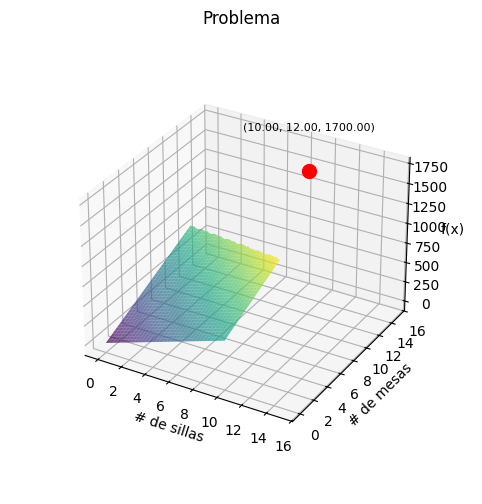

In [31]:
x_1 = np.linspace(0,15,100)
x_2 = np.linspace(0,15,100)
(X_1, X_2) = np.meshgrid(x_1, x_2)


condicion1 = 2*X_1 + 5*X_2 <= 60
condicion2 = X_1 + 2*X_2 <= 40
condicion3 = X_1 <= 10
region_factible = condicion1 & condicion2 & condicion3
f = np.where(region_factible, 50*X_1 + 50*X_2, np.nan)
fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(8, 6))

surf = ax.plot_surface(X_1, X_2, f, cmap="viridis", alpha=0.7)
punto_x1 = solucion.x[0]
punto_x2 = solucion.x[1]
valor_objetivo = -solucion.fun
ax.scatter(punto_x1, punto_x2, valor_objetivo, color='red', s=100, label=f'Solución óptima\n({punto_x1:.2f}, {punto_x2:.2f}, {valor_objetivo:.2f})')
ax.text(punto_x1, punto_x2, valor_objetivo+500, f'({punto_x1:.2f}, {punto_x2:.2f}, {valor_objetivo:.2f})',
        color='black', ha='center', fontsize=8)

ax.set_xlabel("# de sillas")
ax.set_ylabel("# de mesas")
ax.set_zlabel("f(x)")
ax.set_box_aspect(aspect=None, zoom=0.8)
ax.set(title = 'Problema')

plt.show()

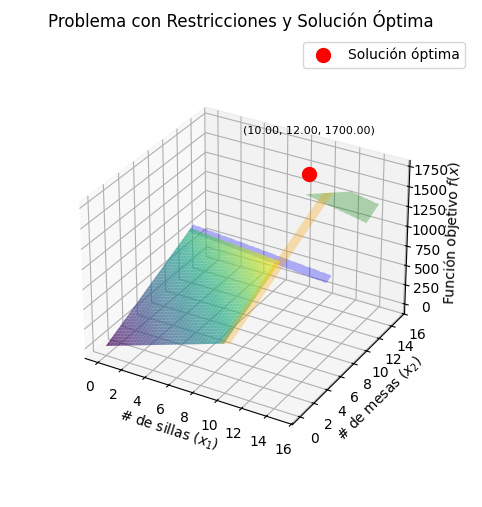

In [32]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(8, 6))

# Definimos el rango de x1 y x2
x_1 = np.linspace(0, 15, 200)
x_2 = np.linspace(0, 15, 200)
(X_1, X_2) = np.meshgrid(x_1, x_2)

# Función objetivo
f = 50*X_1 + 50*X_2

# Restricciones
condicion1 = 2*X_1 + 5*X_2 <= 60
condicion2 = X_1 + 2*X_2 <= 40
condicion3 = X_1 <= 10

region_factible = condicion1 & condicion2 & condicion3

# Solo graficamos f en la región factible
f_region = np.where(region_factible, f, np.nan)

# Superficie de función objetivo
surf = ax.plot_surface(X_1, X_2, f_region, cmap="viridis", alpha=0.7)

# -----------------------------
# Ahora los planos de restricciones
# -----------------------------

# Restricción 1: 2x1 + 5x2 = 60
Z1 = 50*X_1 + 50*X_2  # misma función objetivo para mostrar en misma escala
mask1 = np.isclose(2*X_1 + 5*X_2, 60, atol=2)  # pequeño margen de tolerancia
ax.plot_surface(X_1, X_2, np.where(mask1, Z1, np.nan), color='blue', alpha=0.3)

# Restricción 2: x1 + 2x2 = 40
mask2 = np.isclose(X_1 + 2*X_2, 40, atol=2)
ax.plot_surface(X_1, X_2, np.where(mask2, Z1, np.nan), color='green', alpha=0.3)

# Restricción 3: x1 = 10
mask3 = np.isclose(X_1, 10, atol=0.5)
ax.plot_surface(X_1, X_2, np.where(mask3, Z1, np.nan), color='orange', alpha=0.3)

# -----------------------------
# Punto óptimo
# -----------------------------
punto_x1 = solucion.x[0]
punto_x2 = solucion.x[1]
valor_objetivo = -solucion.fun  # invertimos signo porque linprog minimiza

# Graficamos el punto óptimo
ax.scatter(punto_x1, punto_x2, valor_objetivo, color='red', s=100, label='Solución óptima')
ax.text(punto_x1, punto_x2, valor_objetivo+500, f'({punto_x1:.2f}, {punto_x2:.2f}, {valor_objetivo:.2f})',
        color='black', ha='center', fontsize=8)

# Etiquetas
ax.set_xlabel("# de sillas ($x_1$)")
ax.set_ylabel("# de mesas ($x_2$)")
ax.set_zlabel("Función objetivo $f(x)$")
ax.set_box_aspect(aspect=None, zoom=0.8)
ax.set(title='Problema con Restricciones y Solución Óptima')

# Leyenda
ax.legend()

plt.show()
